# Midfielder Interceptions Model

Predict **interceptions per 90 minutes** for midfielders.

- Train: GW 20-32 | Test: GW 33-35 | Predict: GW 36+
- Filter: minutes_played > 30 (avoid sub outliers)
- Scoring: +2 pts per interception (MID only)
- At prediction time, scale by assumed minutes: `int_pts = pred_int_per_90 Ã— (mins/90) Ã— 2`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

sns.set_style('whitegrid')
print('Imports OK')

Imports OK


## 1. Load Data

In [2]:
# Resolve data dir relative to this notebook's location
data_dir = Path(__file__).parent.parent.parent / 'data' if '__file__' in dir() else Path('../../data')
# Fallback: if running from repo root (e.g. VS Code), adjust path
if not (data_dir / 'player_stats_gw1.csv').exists():
    data_dir = Path('data')

csv_files = sorted(data_dir.glob('player_stats_gw*.csv'))

dfs = [pd.read_csv(f) for f in csv_files]
df_all = pd.concat(dfs, ignore_index=True)

# Filter: midfielders only, played > 30 mins (avoid sub outliers)
df = df_all[(df_all['position'] == 'MID') & (df_all['minutes_played'] > 30)].copy()
df = df.sort_values(['player_id', 'gameweek']).reset_index(drop=True)

print(f'Loaded {len(csv_files)} gameweeks')
print(f'All rows: {len(df_all):,}')
print(f'MID rows (mins > 30): {len(df):,}')
print(f'Gameweeks: {df["gameweek"].min()}-{df["gameweek"].max()}')

Loaded 35 gameweeks
All rows: 83,698
MID rows (mins > 30): 10,159
Gameweeks: 1-35


In [3]:
## Data integrity checks â€” raw load

errors = []

# 1. All rows are MID
non_mid = df[df['position'] != 'MID']
if len(non_mid): errors.append(f'FAIL: {len(non_mid)} non-MID rows after filter')

# 2. All rows have mins > 30
low_mins = df[df['minutes_played'] <= 30]
if len(low_mins): errors.append(f'FAIL: {len(low_mins)} rows with mins <= 30 after filter')

# 3. No duplicate player+GW+opponent (true duplicates â€” same game twice)
dups = df.groupby(['player_id', 'gameweek', 'opponent_id']).size()
dups = dups[dups > 1]
if len(dups): errors.append(f'FAIL: {len(dups)} duplicate player+GW+opponent rows')

# 4. interceptions is never negative
neg_int = df[df['interceptions'] < 0]
if len(neg_int): errors.append(f'FAIL: {len(neg_int)} rows with negative interceptions')

# 5. minutes_played is never > 120 (extra time max)
bad_mins = df[df['minutes_played'] > 120]
if len(bad_mins): errors.append(f'FAIL: {len(bad_mins)} rows with minutes_played > 120')

# Report
dgw_count = (df.groupby(['player_id','gameweek'])['opponent_id'].nunique() > 1).sum()
if errors:
    for e in errors: print(e)
else:
    print(f'OK: all raw data checks passed')
    print(f'    {len(df):,} rows | {df["player_id"].nunique()} players | {df["gameweek"].nunique()} gameweeks')
    print(f'    {dgw_count} DGW appearances (same player, 2 different opponents in one GW â€” expected)')

OK: all raw data checks passed
    10,159 rows | 613 players | 35 gameweeks
    1656 DGW appearances (same player, 2 different opponents in one GW â€” expected)


## 2. Load Fixtures & Squads

Reads from pre-fetched data files. Run `python data/fetch_fixtures.py` to update.

In [4]:
# Load pre-fetched fixture and squad data
with open(data_dir / 'fixtures_remaining.json') as f:
    remaining_fixtures = json.load(f)

with open(data_dir / 'squads.json') as f:
    squads_data = json.load(f)

squads_by_id = {s['id']: s for s in squads_data}

print(f'Loaded {len(remaining_fixtures)} future gameweeks')
print(f'Loaded {len(squads_data)} squads')
for gw, games in sorted(remaining_fixtures.items(), key=lambda x: int(x[0])):
    print(f'  GW {gw}: {len(games)} games')

Loaded 5 future gameweeks
Loaded 72 squads
  GW 36: 70 games
  GW 37: 46 games
  GW 38: 57 games
  GW 39: 40 games
  GW 40: 36 games


## 3. Build Features

In [5]:
# Target: interceptions per 90 minutes
df['int_per_90'] = df['interceptions'] / (df['minutes_played'] / 90)

# Player features (per-player via transform, shifted to avoid leakage)
df['int_per_90_last10'] = df.groupby('player_id')['int_per_90'].transform(
    lambda x: x.shift(1).rolling(window=10, min_periods=1).mean()
)
df['int_per_90_season'] = df.groupby('player_id')['int_per_90'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
)

# Games played so far (cumulative count of prior appearances for this player)
df['games_played'] = df.groupby('player_id').cumcount()

# Cumulative minutes played so far (for filtering at prediction time)
df['total_mins'] = df.groupby('player_id')['minutes_played'].cumsum()

# Opposition feature: expanding avg int/90 conceded by each opponent (no future leakage)
# For each gameweek, only uses data from PRIOR gameweeks
df = df.sort_values(['opponent_id', 'gameweek']).reset_index(drop=True)
df['opp_avg_int_conceded'] = df.groupby('opponent_id')['int_per_90'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
)
df['opp_avg_int_conceded'] = df['opp_avg_int_conceded'].fillna(df['int_per_90'].mean())
df = df.sort_values(['player_id', 'gameweek']).reset_index(drop=True)

# Match context
difficulty_map = {'easy': 0, 'medium': 1, 'hard': 2}
df['fixture_diff'] = df['fixture_difficulty'].map(difficulty_map).fillna(1)
df['is_home'] = (df['is_home'] == 'H').astype(int)

# Add squad league info for charts later
squad_league = {s['id']: {10: 'Championship', 11: 'League One', 12: 'League Two'}[s['competitionId']]
                for s in squads_data if s['competitionId'] in (10, 11, 12)}
df['league'] = df['squad_id'].map(squad_league)

print('Features built (no future leakage in opp stats).')
print(f'\nInt/90 stats:')
print(df['int_per_90'].describe().round(3))

Features built (no future leakage in opp stats).

Int/90 stats:
count    10159.000
mean         0.805
std          1.066
min          0.000
25%          0.000
50%          0.000
75%          1.233
max          8.182
Name: int_per_90, dtype: float64


In [6]:
## Feature integrity checks — no leakage, correct calculations

# B. Dack has no DGW rows and 26 appearances — clean player for spot checks
errors = []
player_name = 'B. Dack'
p = df[df['display_name'] == player_name].sort_values('gameweek').reset_index(drop=True)

# --- Check 1: int_per_90 formula is correct ---
expected_per90 = p['interceptions'] / (p['minutes_played'] / 90)
if not np.allclose(p['int_per_90'], expected_per90, atol=1e-6):
    errors.append('FAIL: int_per_90 formula wrong')

# --- Check 2: int_per_90_season no leakage ---
# Row 1 must equal row 0's int_per_90 (no other prior data)
row1_expected = p['int_per_90'].iloc[0]
row1_actual = p['int_per_90_season'].iloc[1]
if not np.isclose(row1_actual, row1_expected, atol=1e-6):
    errors.append(f'FAIL: int_per_90_season row 1 = {row1_actual:.4f}, expected {row1_expected:.4f}')

# Row 10 must be mean of rows 0..9
row10_expected = p['int_per_90'].iloc[:10].mean()
row10_actual = p['int_per_90_season'].iloc[10]
if not np.isclose(row10_actual, row10_expected, atol=1e-6):
    errors.append(f'FAIL: int_per_90_season row 10 = {row10_actual:.4f}, expected {row10_expected:.4f}')

# --- Check 3: int_per_90_last10 no leakage ---
# Row 15 must be mean of rows 5..14 (window=10, shift=1)
row15_expected = p['int_per_90'].iloc[5:15].mean()
row15_actual = p['int_per_90_last10'].iloc[15]
if not np.isclose(row15_actual, row15_expected, atol=1e-6):
    errors.append(f'FAIL: int_per_90_last10 row 15 = {row15_actual:.4f}, expected {row15_expected:.4f}')

# --- Check 4: opp_avg_int_conceded is within valid range (0 to max int/90) ---
max_int = df['int_per_90'].max()
if (df['opp_avg_int_conceded'] < 0).any():
    errors.append('FAIL: negative opp_avg_int_conceded values')
if (df['opp_avg_int_conceded'] > max_int + 0.01).any():
    errors.append(f'FAIL: opp_avg_int_conceded exceeds max possible ({max_int:.2f})')

# opp_avg_int_conceded should never equal current game's int_per_90 for
# an opponent's very first game (only fallback or prior history is possible)
# Check it's always plausible: value at any row is a mean of 0+ prior games (bounded by max)
if df['opp_avg_int_conceded'].isna().any():
    errors.append('FAIL: NaN in opp_avg_int_conceded after fillna')

# --- Check 5: games_played covers 0..N-1 per player (no gaps, no duplicates) ---
bad = df.groupby('player_id').apply(
    lambda g: sorted(g['games_played'].tolist()) != list(range(len(g)))
)
if bad.any():
    errors.append(f'FAIL: games_played has gaps or duplicates for {bad.sum()} players')

# --- Spot check: Norwood GW35 int_per_90_last10 ---
# Manually: last 10 qualifying games before GW35 for Norwood were mostly 0s
# Expected value is 0.30 based on manual trace
norwood_gw35 = df[(df['display_name'] == 'O. Norwood') & (df['gameweek'] == 35)]
if len(norwood_gw35) > 0:
    actual_val = norwood_gw35['int_per_90_last10'].iloc[0]
    if not np.isclose(actual_val, 0.30, atol=0.01):
        errors.append(f'FAIL: Norwood GW35 last10 = {actual_val:.3f}, expected ~0.300')
    else:
        print(f'Norwood GW35 int_per_90_last10 = {actual_val:.3f} (expected 0.30) OK')
        print(f'  His 3 interceptions in GW35 NOT in this value (shift=1 working)')

if errors:
    for e in errors: print(e)
else:
    print('OK: all feature checks passed — no data leakage detected')

Norwood GW35 int_per_90_last10 = 0.300 (expected 0.30) OK
  His 3 interceptions in GW35 NOT in this value (shift=1 working)
OK: all feature checks passed — no data leakage detected


## 4. Train & Test Split

In [7]:
# Filter to GW >= 20, drop rows without enough history
df_model = df[df['gameweek'] >= 20].copy()
df_model = df_model.dropna(subset=['int_per_90_last10', 'int_per_90_season'])

features = ['int_per_90_last10', 'int_per_90_season', 'opp_avg_int_conceded', 'total_mins', 'fixture_diff', 'is_home']
target = 'int_per_90'

print(f'Model rows (GW >= 20): {len(df_model):,}')
print(f'Train (GW 20-32): {len(df_model[df_model["gameweek"] <= 32]):,}')
print(f'Test  (GW 33-35): {len(df_model[df_model["gameweek"].isin([33,34,35])]):,}')

Model rows (GW >= 20): 5,265


Train (GW 20-32): 4,402
Test  (GW 33-35): 863


In [8]:
## Train/test split checks

errors = []

train = df_model[df_model['gameweek'] <= 32]
test = df_model[df_model['gameweek'].isin([33, 34, 35])]

# 1. No test gameweeks in train
if train['gameweek'].max() >= 33:
    errors.append(f'FAIL: train contains GW {train["gameweek"].max()} (should be <= 32)')

# 2. No train gameweeks in test
if test['gameweek'].min() < 33:
    errors.append(f'FAIL: test contains GW {test["gameweek"].min()} (should be >= 33)')

# 3. No NaN in any feature column
for feat in features:
    n_nan = df_model[feat].isna().sum()
    if n_nan > 0:
        errors.append(f'FAIL: {n_nan} NaN values in feature "{feat}"')

# 4. No NaN in target
n_nan_target = df_model[target].isna().sum()
if n_nan_target > 0:
    errors.append(f'FAIL: {n_nan_target} NaN values in target "{target}"')

# 5. Target is non-negative (can't have negative interceptions)
if (df_model[target] < 0).any():
    errors.append('FAIL: negative values in int_per_90 target')

# 6. games_played in model rows >= 1 (must have at least one prior game for features)
if (df_model['games_played'] < 1).any():
    errors.append(f'FAIL: {(df_model["games_played"] < 1).sum()} model rows have games_played < 1')

if errors:
    for e in errors: print(e)
else:
    print('OK: all train/test split checks passed')
    print(f'    Train: {len(train):,} rows (GW 20-32) | Test: {len(test):,} rows (GW 33-35)')
    print(f'    Features: no NaN in any of {len(features)} columns')
    print(f'    Target range: {df_model[target].min():.2f} â€“ {df_model[target].max():.2f}')

OK: all train/test split checks passed


    Train: 4,402 rows (GW 20-32) | Test: 863 rows (GW 33-35)
    Features: no NaN in any of 6 columns
    Target range: 0.00 â€“ 8.18


## 5. Walk-Forward Validation (GW 33-35)

In [9]:
test_gws = [33, 34, 35]

models = {
    'LinearRegression': LinearRegression(),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                            subsample=0.8, colsample_bytree=0.8, random_state=42),
}

all_results = {name: [] for name in models}

for test_gw in test_gws:
    train = df_model[df_model['gameweek'] < test_gw]
    test = df_model[df_model['gameweek'] == test_gw]
    
    if len(train) == 0 or len(test) == 0:
        continue
    
    for name, model in models.items():
        model.fit(train[features], train[target])
        y_pred = model.predict(test[features])
        y_test = test[target].values
        
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        all_results[name].append({'GW': test_gw, 'MAE': mae, 'RMSE': rmse, 'R2': r2})

# Print comparison
print('=== Model Comparison (GW 33-35 Walk-Forward) ===\n')
print(f'{"Model":<20s} {"MAE":>8s} {"RMSE":>8s} {"RÂ²":>8s}')
print('-' * 48)

best_model_name = None
best_mae = float('inf')

for name, res in all_results.items():
    avg_mae = np.mean([r['MAE'] for r in res])
    avg_rmse = np.mean([r['RMSE'] for r in res])
    avg_r2 = np.mean([r['R2'] for r in res])
    print(f'{name:<20s} {avg_mae:>8.3f} {avg_rmse:>8.3f} {avg_r2:>8.3f}')
    if avg_mae < best_mae:
        best_mae = avg_mae
        best_model_name = name

print(f'\nBest model: {best_model_name} (lowest MAE)')

# Per-GW breakdown
print(f'\n=== Per-Gameweek Breakdown ===')
for gw in test_gws:
    print(f'\nGW {gw}:')
    for name, res in all_results.items():
        r = [x for x in res if x['GW'] == gw][0]
        print(f'  {name:<20s} MAE={r["MAE"]:.3f}  RMSE={r["RMSE"]:.3f}  RÂ²={r["R2"]:.3f}')

# Feature importance for XGBoost
xgb_model = models['XGBoost']
xgb_model.fit(df_model[df_model['gameweek'] < 33][features], df_model[df_model['gameweek'] < 33][target])
print(f'\n=== XGBoost Feature Importance ===')
for feat, imp in sorted(zip(features, xgb_model.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f'  {feat:25s} {imp:.4f}')

# Linear regression coefficients for comparison
lr_model = models['LinearRegression']
lr_model.fit(df_model[df_model['gameweek'] < 33][features], df_model[df_model['gameweek'] < 33][target])
print(f'\n=== Linear Regression Coefficients ===')
for feat, coef in sorted(zip(features, lr_model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {feat:25s} {coef:+.4f}')
print(f'  {"intercept":25s} {lr_model.intercept_:+.4f}')

=== Model Comparison (GW 33-35 Walk-Forward) ===

Model                     MAE     RMSE      RÂ²
------------------------------------------------
LinearRegression        0.812    0.994    0.048
XGBoost                 0.807    0.993    0.048

Best model: XGBoost (lowest MAE)

=== Per-Gameweek Breakdown ===

GW 33:
  LinearRegression     MAE=0.826  RMSE=1.016  RÂ²=0.040
  XGBoost              MAE=0.836  RMSE=1.027  RÂ²=0.019

GW 34:
  LinearRegression     MAE=0.801  RMSE=0.992  RÂ²=0.015
  XGBoost              MAE=0.808  RMSE=1.006  RÂ²=-0.014

GW 35:
  LinearRegression     MAE=0.809  RMSE=0.974  RÂ²=0.089
  XGBoost              MAE=0.777  RMSE=0.947  RÂ²=0.140

=== XGBoost Feature Importance ===
  int_per_90_season         0.2836
  opp_avg_int_conceded      0.1540
  int_per_90_last10         0.1503
  total_mins                0.1502
  is_home                   0.1319
  fixture_diff              0.1300

=== Linear Regression Coefficients ===
  opp_avg_int_conceded      +0.4684
  int_pe

## 5b. Teams Allowing Most Interceptions (by League)

Which opponents let midfielders intercept the most per 90?

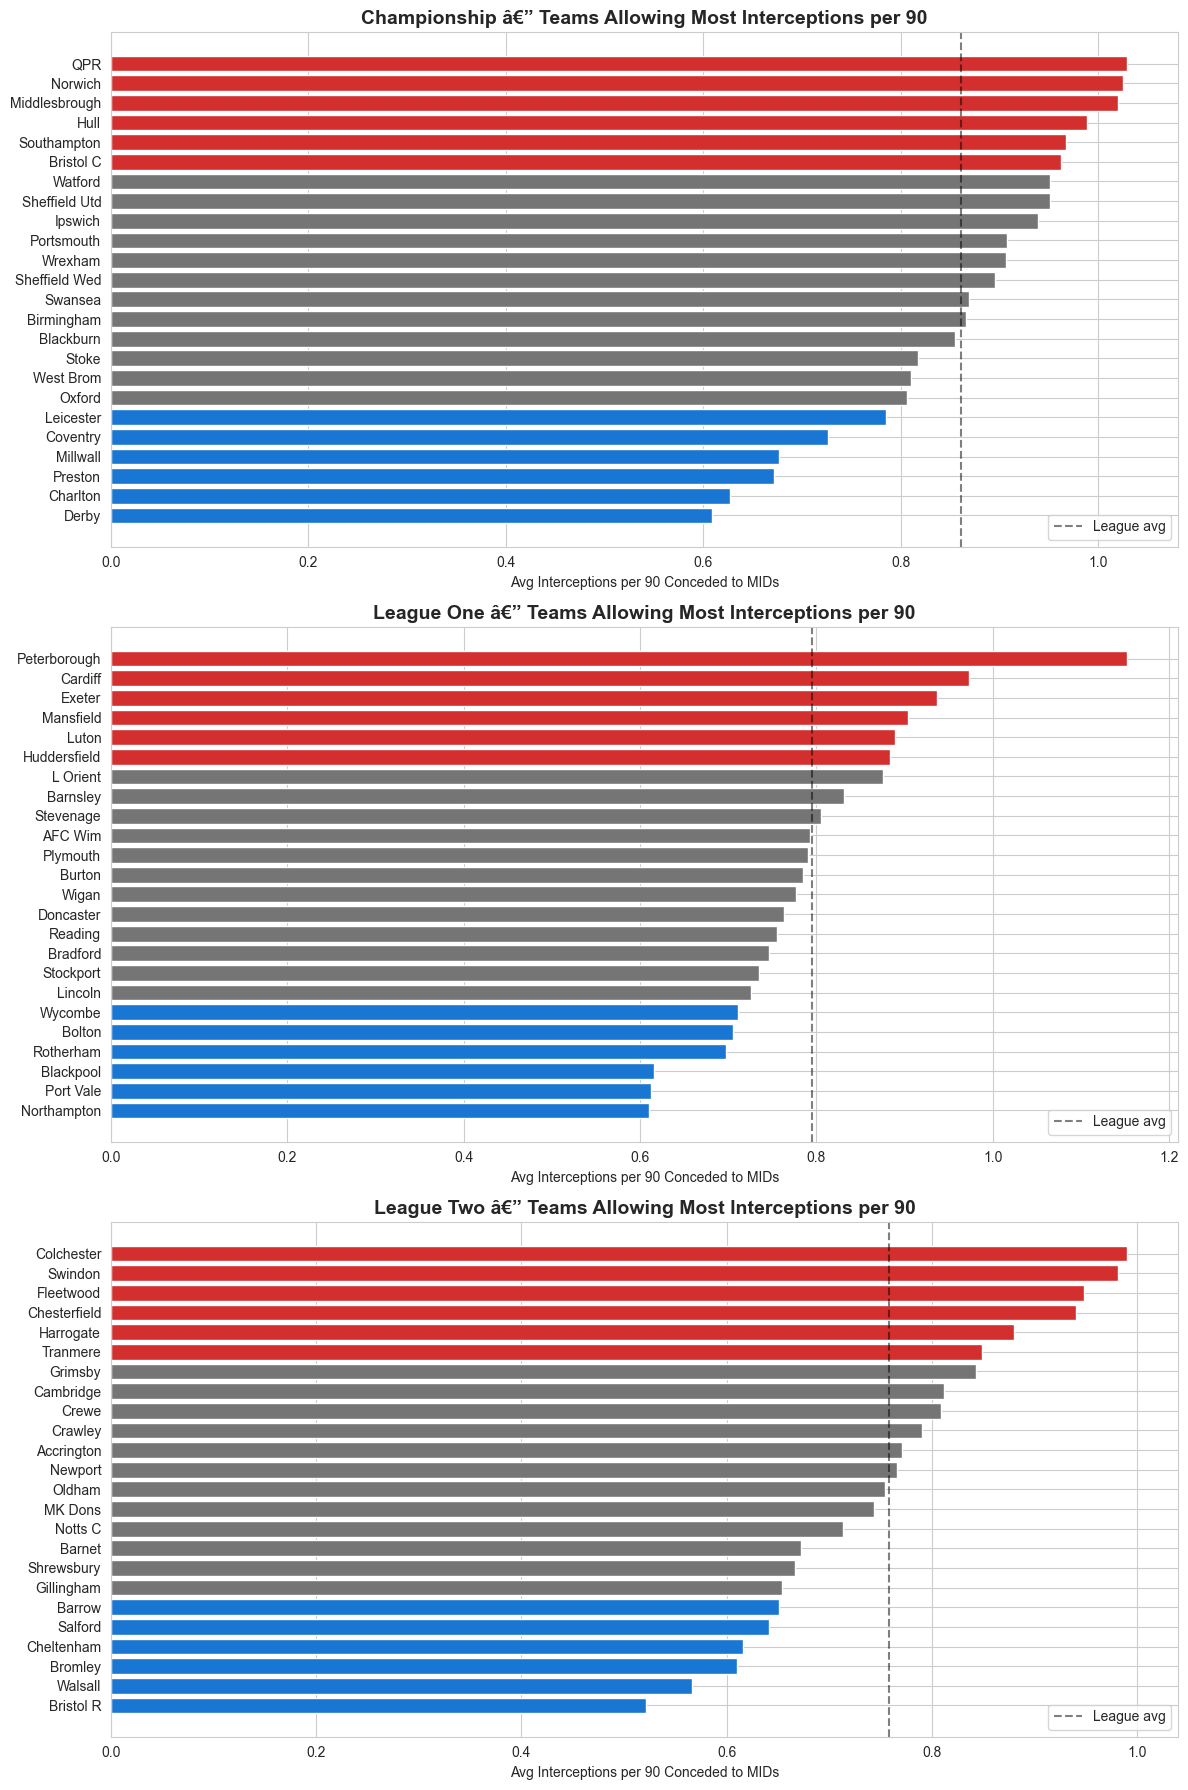


Championship â€” Top 5 teams allowing most int/90:
  QPR                  1.03 int/90 (146 games)
  Norwich              1.02 int/90 (133 games)
  Middlesbrough        1.02 int/90 (149 games)
  Hull                 0.99 int/90 (144 games)
  Southampton          0.97 int/90 (140 games)

League One â€” Top 5 teams allowing most int/90:
  Peterborough         1.15 int/90 (138 games)
  Cardiff              0.97 int/90 (147 games)
  Exeter               0.94 int/90 (152 games)
  Mansfield            0.90 int/90 (139 games)
  Luton                0.89 int/90 (152 games)

League Two â€” Top 5 teams allowing most int/90:
  Colchester           0.99 int/90 (147 games)
  Swindon              0.98 int/90 (136 games)
  Fleetwood            0.95 int/90 (137 games)
  Chesterfield         0.94 int/90 (137 games)
  Harrogate            0.88 int/90 (152 games)


In [10]:
# Build opponent league lookup (opponent_id -> league name)
opp_league = {s['id']: {10: 'Championship', 11: 'League One', 12: 'League Two'}[s['competitionId']]
              for s in squads_data if s['competitionId'] in (10, 11, 12)}

# Avg int/90 conceded by each opponent (using all data, this is for analysis not model input)
opp_int = df.groupby('opponent_id').agg(
    avg_int_per_90=('int_per_90', 'mean'),
    opponent_name=('opponent_name', 'first'),
    games=('int_per_90', 'count')
).reset_index()
opp_int['league'] = opp_int['opponent_id'].map(opp_league)
opp_int = opp_int.dropna(subset=['league'])

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

for ax, league in zip(axes, ['Championship', 'League One', 'League Two']):
    league_data = opp_int[opp_int['league'] == league].sort_values('avg_int_per_90', ascending=True)
    
    colors = ['#d32f2f' if v >= league_data['avg_int_per_90'].quantile(0.75)
              else '#1976d2' if v <= league_data['avg_int_per_90'].quantile(0.25)
              else '#757575' for v in league_data['avg_int_per_90']]
    
    ax.barh(league_data['opponent_name'], league_data['avg_int_per_90'], color=colors)
    ax.set_xlabel('Avg Interceptions per 90 Conceded to MIDs')
    ax.set_title(f'{league} â€” Teams Allowing Most Interceptions per 90', fontsize=14, fontweight='bold')
    ax.axvline(league_data['avg_int_per_90'].mean(), color='black', linestyle='--', alpha=0.5, label='League avg')
    ax.legend()

plt.tight_layout()
plt.savefig(data_dir / 'opp_interceptions_by_league.png', dpi=150, bbox_inches='tight')
plt.show()

# Print top 5 per league
for league in ['Championship', 'League One', 'League Two']:
    top = opp_int[opp_int['league'] == league].nlargest(5, 'avg_int_per_90')
    print(f'\n{league} â€” Top 5 teams allowing most int/90:')
    for _, r in top.iterrows():
        print(f"  {r['opponent_name']:20s} {r['avg_int_per_90']:.2f} int/90 ({int(r['games'])} games)")

## 6. Case Study

In [11]:
def int_predictions(player_name, assumed_mins=90):
    """Predict interceptions for a midfielder (GW 33-35 test period).
    
    Predicts int/90, then scales: int_pts = pred_int_per_90 Ã— (assumed_mins/90) Ã— 2
    """
    player_data = df_model[df_model['display_name'].str.contains(player_name, case=False, na=False)]
    if len(player_data) == 0:
        print(f'Player "{player_name}" not found')
        return
    
    player_id = player_data['player_id'].iloc[0]
    full_name = player_data['display_name'].iloc[0]
    
    player_test = df_model[(df_model['player_id'] == player_id) & 
                           (df_model['gameweek'].isin([33, 34, 35]))]
    if len(player_test) == 0:
        print(f'No test data for {full_name}')
        return
    
    # Train on GW < 33
    train = df_model[df_model['gameweek'] < 33]
    model = LinearRegression().fit(train[features], train[target])
    
    y_pred = model.predict(player_test[features])
    y_actual = player_test['int_per_90'].values
    mins_scale = assumed_mins / 90
    
    print(f'=== {full_name}: Interceptions (GW 33-35) ===')
    print(f'    Assumed minutes: {assumed_mins}\n')
    
    rows = []
    for idx, (_, row) in enumerate(player_test.iterrows()):
        actual_mins = int(row['minutes_played'])
        actual_scale = actual_mins / 90
        rows.append({
            'GW': int(row['gameweek']),
            'Opponent': row['opponent_name'],
            'H/A': 'H' if row['is_home'] == 1 else 'A',
            'Int/90 Szn': f"{row['int_per_90_season']:.2f}",
            'Int/90 L10': f"{row['int_per_90_last10']:.2f}",
            'Opp Conc': f"{row['opp_avg_int_conceded']:.2f}",
            'Mins': actual_mins,
            'Pred Int/90': f"{y_pred[idx]:.2f}",
            'Act Int/90': f"{y_actual[idx]:.2f}",
            f'Pts ({assumed_mins}m)': f"{y_pred[idx] * mins_scale * 2:.1f}",
            f'Pts (act m)': f"{y_pred[idx] * actual_scale * 2:.1f}",
            'Pts actual': f"{row['interceptions'] * 2}",
        })
    
    print(pd.DataFrame(rows).to_string(index=False))
    
    mae = mean_absolute_error(y_actual, y_pred)
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    print(f'\nInt/90 â€” MAE: {mae:.2f}, RMSE: {rmse:.2f}')

int_predictions('L. Wing')
print()
int_predictions('S. Bradley')

=== L. Wing: Interceptions (GW 33-35) ===
    Assumed minutes: 90

 GW  Opponent H/A Int/90 Szn Int/90 L10 Opp Conc  Mins Pred Int/90 Act Int/90 Pts (90m) Pts (act m) Pts actual
 33  Plymouth   H       1.34       1.70     0.82    90        1.18       1.00       2.4         2.4          2
 33    Burton   A       1.33       1.70     0.78    90        1.13       2.00       2.3         2.3          4
 34 Stevenage   A       1.35       1.80     0.82    90        1.18       1.00       2.4         2.4          2
 35     Wigan   H       1.34       1.90     0.75    90        1.15       4.00       2.3         2.3          8

Int/90 â€” MAE: 1.02, RMSE: 1.50

Player "S. Bradley" not found


In [12]:
int_predictions('O. Norwood')

=== O. Norwood: Interceptions (GW 33-35) ===
    Assumed minutes: 90

 GW    Opponent H/A Int/90 Szn Int/90 L10 Opp Conc  Mins Pred Int/90 Act Int/90 Pts (90m) Pts (act m) Pts actual
 33 Northampton   H       1.38       1.13     0.55    90        1.01       0.00       2.0         2.0          0
 33     Lincoln   A       1.43       1.33     0.71    90        1.12       0.00       2.2         2.2          0
 34       Luton   A       1.34       0.63     0.90    90        1.12       0.00       2.2         2.2          0
 35     AFC Wim   H       1.30       0.30     0.77    90        1.04       3.00       2.1         2.1          6

Int/90 â€” MAE: 1.30, RMSE: 1.36


In [13]:
int_predictions('B. Knight')

=== B. Knight: Interceptions (GW 33-35) ===
    Assumed minutes: 90

 GW   Opponent H/A Int/90 Szn Int/90 L10 Opp Conc  Mins Pred Int/90 Act Int/90 Pts (90m) Pts (act m) Pts actual
 33    Walsall   A       0.51       0.66     0.59    74        0.63       1.22       1.3         1.0          2
 33 Gillingham   H       0.54       0.76     0.67    90        0.68       0.00       1.4         1.4          0
 34    Salford   H       0.55       0.58     0.65    90        0.68       0.00       1.4         1.4          0
 35     Barnet   A       0.52       0.33     0.68    90        0.65       0.00       1.3         1.3          0

Int/90 â€” MAE: 0.65, RMSE: 0.65


## 7. GW 36+ Predictions

In [14]:
# Train best model on ALL available data (GW 20-35)
if best_model_name == 'XGBoost':
    model_final = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1,
                               subsample=0.8, colsample_bytree=0.8, random_state=42)
else:
    model_final = LinearRegression()

model_final.fit(df_model[features], df_model[target])
print(f'Using best model: {best_model_name}')

# Compute CURRENT features for each player — includes all games up to and including GW35.
# (Training uses shift=1 to avoid leakage, but for prediction we WANT the full picture.)
current = (
    df.sort_values(['player_id', 'gameweek'])
    .groupby('player_id')
    .agg(
        display_name=('display_name', 'last'),
        squad_id=('squad_id', 'last'),
        int_per_90_season=('int_per_90', 'mean'),
        int_per_90_last10=('int_per_90', lambda x: x.iloc[-10:].mean()),
        games_played=('int_per_90', 'count'),
        total_mins=('minutes_played', 'sum'),
    )
    .reset_index()
)

# Filter to players with 1000+ total minutes this season
current = current[current['total_mins'] >= 1000].copy()
print(f'Players with 1000+ mins: {len(current)}')

# Sanity check: Norwood's season avg should now include his GW35 3 interceptions
norwood_check = current[current['display_name'] == 'O. Norwood']
if len(norwood_check):
    print(f'Norwood int/90 season (incl GW35): {norwood_check["int_per_90_season"].iloc[0]:.3f}')
    print(f'Norwood int/90 last10 (incl GW35): {norwood_check["int_per_90_last10"].iloc[0]:.3f}')

# Latest opp_avg_int_conceded per opponent (expanded up to most recent game)
opp_latest = df.sort_values('gameweek').groupby('opponent_id')['opp_avg_int_conceded'].last().to_dict()
opp_fallback = df['int_per_90'].mean()

# Build predictions for GW 36
gw = '36'
if gw not in remaining_fixtures:
    print(f'No fixture data for GW {gw}')
else:
    squad_fixtures = {}
    for fix in remaining_fixtures[gw]:
        for side, squad_id, opp_id, opp_name, diff_key in [
            ('home', fix['home_id'], fix['away_id'], fix['away_name'], 'home_difficulty'),
            ('away', fix['away_id'], fix['home_id'], fix['home_name'], 'away_difficulty'),
        ]:
            squad_fixtures.setdefault(squad_id, []).append({
                'opponent_name': opp_name,
                'opponent_id': opp_id,
                'is_home': 1 if side == 'home' else 0,
                'fixture_diff': {'easy': 0, 'medium': 1, 'hard': 2}.get(fix[diff_key], 1),
            })

    predictions = []
    for _, player in current.iterrows():
        squad_id = player['squad_id']
        if squad_id not in squad_fixtures:
            continue

        for fix in squad_fixtures[squad_id]:
            opp_val = opp_latest.get(fix['opponent_id'], opp_fallback)

            X = pd.DataFrame([{
                'int_per_90_last10': player['int_per_90_last10'],
                'int_per_90_season': player['int_per_90_season'],
                'opp_avg_int_conceded': opp_val,
                'total_mins': player['total_mins'],
                'fixture_diff': fix['fixture_diff'],
                'is_home': fix['is_home'],
            }])

            pred_int_per_90 = model_final.predict(X)[0]

            predictions.append({
                'Player': player['display_name'],
                'Team': squads_by_id.get(squad_id, {}).get('shortName', ''),
                'Opponent': fix['opponent_name'],
                'H/A': 'H' if fix['is_home'] else 'A',
                'Difficulty': ['easy', 'medium', 'hard'][fix['fixture_diff']],
                'Int/90 Szn': f"{player['int_per_90_season']:.2f}",
                'Int/90 L10': f"{player['int_per_90_last10']:.2f}",
                'Opp Conc': round(opp_val, 2),
                'Games': int(player['games_played']),
                'Tot Mins': int(player['total_mins']),
                'Pred Int/90': round(pred_int_per_90, 2),
                'Pred Pts (90m)': round(pred_int_per_90 * 2, 1),
            })

    pred_df = pd.DataFrame(predictions).sort_values('Pred Pts (90m)', ascending=False)
    print(f'=== GW {gw} Interception Predictions — {best_model_name} (Top 25, 1000+ mins, 90 mins) ===')
    print(pred_df.head(25).to_string(index=False))
    print(f'Total MID predictions: {len(pred_df)}')

Using best model: XGBoost
Players with 1000+ mins: 335
Norwood int/90 season (incl GW35): 1.350
Norwood int/90 last10 (incl GW35): 0.600


=== GW 36 Interception Predictions — XGBoost (Top 25, 1000+ mins, 90 mins) ===
      Player        Team      Opponent H/A Difficulty Int/90 Szn Int/90 L10  Opp Conc  Games  Tot Mins  Pred Int/90  Pred Pts (90m)
 M. Stamenic     Swansea Sheffield Utd   A       easy       1.75       2.18      0.95     26      2014         1.98             4.0
  G. Saville       Luton  Peterborough   H     medium       1.53       1.59      1.16     27      2238         1.92             3.8
     L. Wing     Reading  Huddersfield   A     medium       1.41       2.10      0.89     39      3510         1.88             3.8
   T. Devlin  Portsmouth        Oxford   H       easy       1.96       2.11      0.79     24      2044         1.92             3.8
   T. Devlin  Portsmouth       Norwich   A     medium       1.96       2.11      1.03     24      2044         1.85             3.7
 M. Stamenic     Swansea Middlesbrough   H       hard       1.75       2.18      1.03     26      2014         1.86             3